In [1]:
import os
import math
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from Pred_NN_Classes import PPNet
from Decoder_CLasses.VoronoiDecorder import VoronoiDecoder,VoronoiModelVisualizer
from Training.MainTrain import TrainingConfig, NN_Trainer, Load_Model
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"
    is_ssh = bool(os.environ.get("SSH_CONNECTION") or os.environ.get("SSH_CLIENT"))
    is_headless = not bool(os.environ.get("DISPLAY"))

    # Mac, SSH, or headless sessions: prefer static to avoid X11/VTK display issues.
    if is_mac or is_ssh or is_headless:
        pv.OFF_SCREEN = True
        try:
            pv.set_jupyter_backend("static")
            backend = "static"
        except Exception as exc:
            backend = f"static unavailable ({exc.__class__.__name__})"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


gmesh was loaded successfully!
Code Directory: /home/arash/HDV_Shell
Test Step files Directory: /home/arash/HDV_Shell/Testparts
device: cuda
PyVista backend: static


FullCylinder
Model is meshed using Gmsh tool
MinVolFrac: 0.03646901622414589
Mesh edge length: min=1.01308 max=2.0608 median=1.49004
Selected CAD face index: 0
Number of faces used: 1
Number of sampled points: 13751
Selected-face BBX dimensions: dx=82.0000, dy=81.9983, dz=100.0000
Face is periodic in u direction


2026-05-15 10:05:19.420 (   2.259s) [    75974DEBE600]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


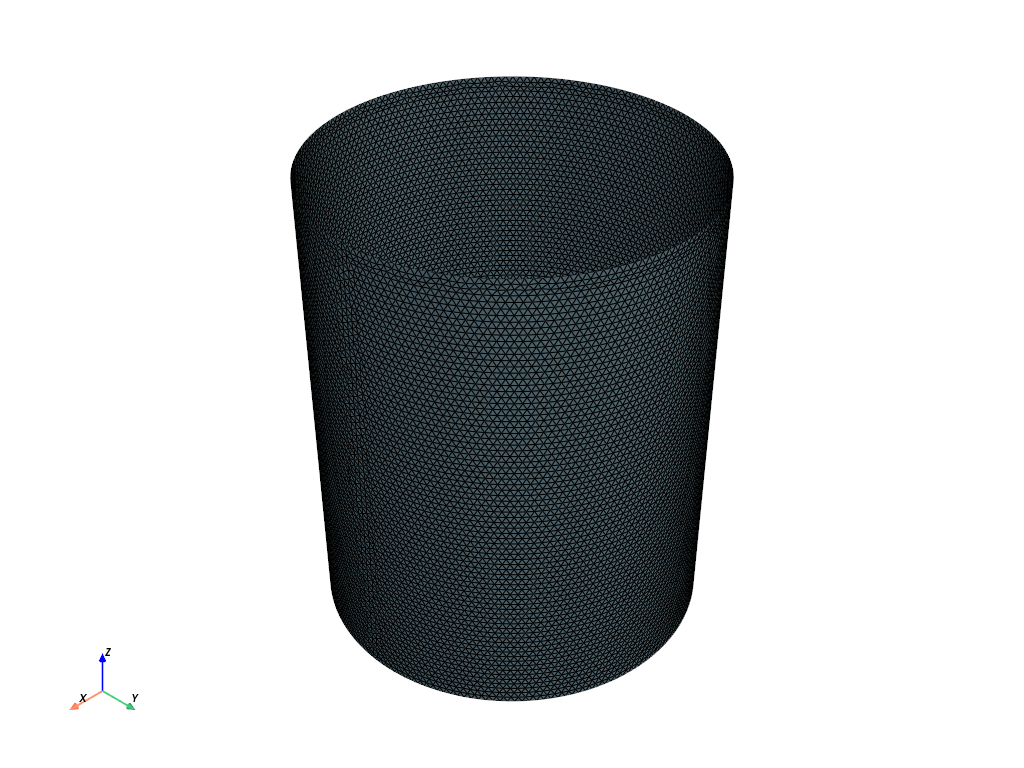

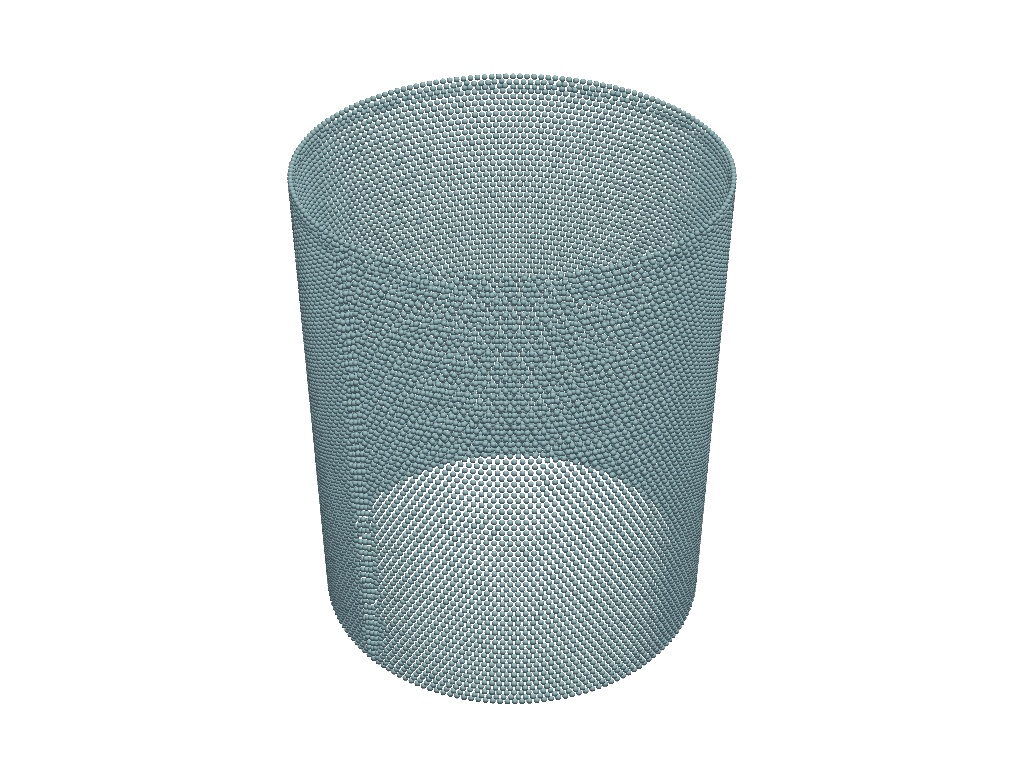

In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"


shape_path = FullCylinder

# Meshing controls
# OCC meshing (global fallback for mode="mesh"):
#   - deflection: smaller -> finer OCC mesh
#   - angle: smaller -> finer OCC mesh on curved regions
# Manual UV-grid meshing (used when freeform_mesher="manual" on supported analytic faces):
#   - n_u, n_v: more samples -> finer UV grid mesh
# Gmsh meshing (used for free-form faces when freeform_mesher is "auto" or "gmsh"):
#   - gmsh_size_scale: smaller -> finer mesh, larger -> coarser mesh
#   - gmsh_algorithm: picks the Gmsh 2D meshing algorithm (6 is a solid default)
# Mesher selection:
#   - freeform_mesher="auto": try Gmsh first, then fall back to OpenCascade
#   - freeform_mesher="gmsh": require Gmsh for free-form faces
#   - freeform_mesher="manual": use UV-grid on supported analytic faces, otherwise OpenCascade

Case_name = shape_path.stem
print(Case_name)
generator = CADTensorGenerator(
    deflection=0.001,
    angle=0.001,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=30  ,
    n_v=30,
    freeform_mesher="auto",   #"auto"
    gmsh_size_scale=0.25,
    gmsh_algorithm=6,
    device=device,
    selected_face_index=0,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=str(shape_path),
    input_ring=1,
    mode="mesh", #"1: mesh" "2:Sampled_points "
    M_per_face=2000,
    pool_size_factor=10,
    fps_pool_factor=4,
    use_fps=True,
    triangulation_max_edge_rel=0.1,
)
uv = tensors["uv"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
faces_ijk = tensors["faces_ijk"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
pv_faces = tensors["pv_faces"]

face_tensor = tensors["face_tensors"][0]
face_u_periodic = bool(face_tensor["u_periodic"])
face_v_periodic = bool(face_tensor["v_periodic"])

bbx_all = list(tensors["BBX"].values())
xmin = min(b["xmin"] for b in bbx_all)
xmax = max(b["xmax"] for b in bbx_all)
ymin = min(b["ymin"] for b in bbx_all)
ymax = max(b["ymax"] for b in bbx_all)
zmin = min(b["zmin"] for b in bbx_all)
zmax = max(b["zmax"] for b in bbx_all)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin

print(f"Selected CAD face index: {generator.selected_face_index}")
print(f"Number of faces used: {tensors['num_faces']}")
print(f"Number of sampled points: {uv.shape[0]}")
print(f"Selected-face BBX dimensions: dx={dx:.4f}, dy={dy:.4f}, dz={dz:.4f}")

if face_u_periodic:
    print("Face is periodic in u direction")
if face_v_periodic:
    print("Face is periodic in v direction")

viz.visualize_show_Model(points_xyz, pv_faces)

pts = points_xyz.detach().cpu().numpy()
cloud = pv.PolyData(pts)
plotter = pv.Plotter()
plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=6)
plotter.show()


=== Voxel Stats ===
brep_bbox: {'xmin': -40.99999999842735, 'xmax': 41.00000000000001, 'ymin': -40.99885204729345, 'ymax': 40.999431997946324, 'zmin': 0.0, 'zmax': 100.0}
mesh: {'nelx': 17, 'nely': 17, 'nelz': 20, 'elemSize': array([6.5999571, 6.5999571, 6.5999571]), 'type': 'grid'}
elem_centers shape: (20, 17, 17, 3)
node_coords shape: (21, 18, 18, 3)
occupied voxels: 1343
total voxels: 5780
occupancy ratio: 0.2323529411764706
voxels with assigned surface samples: 751
occupied voxels with assigned surface samples: 751
voxelized volume: 386099.59915153356
thickness: 13.199914202183356
voxel_size: 6.599957101091678
target approx volume (sum(face_areas)*thickness): 340029.8414104081
volume ratio voxel/target: 1.1354873959004097


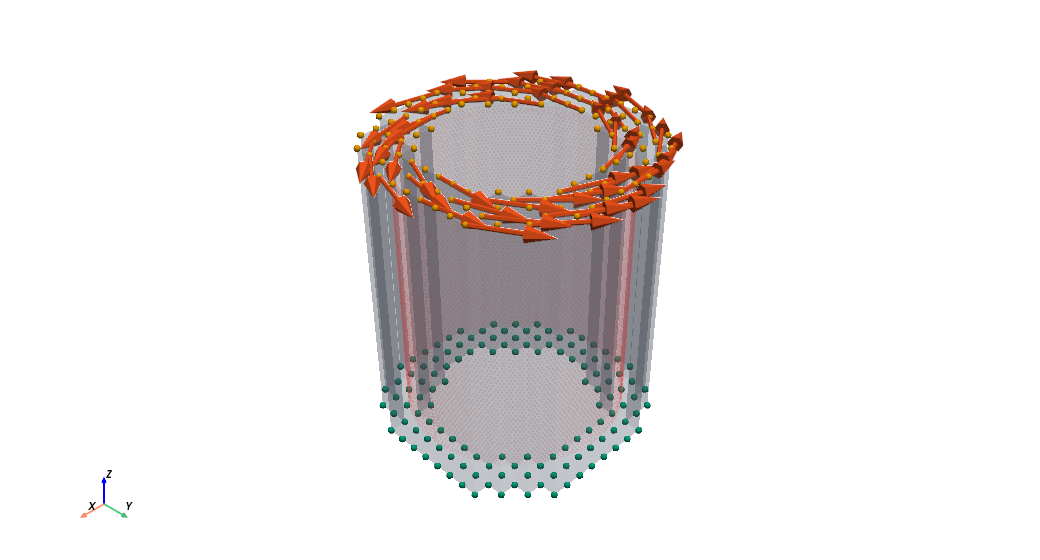

In [3]:

Include_FEM= True
LoadingCase = "Test_Torsion_Z"

voxel_size = (dx+dy+dz)/40
fixed_height_shell= voxel_size*2
tangential_tol = voxel_size*0.8

if(Include_FEM):
    shell_problem = ThickenShell(
        thickness=fixed_height_shell,
        voxel_size=voxel_size,
        extra_layers=1,
        tensors=tensors,
        tangential_tol=tangential_tol,

        # ============================================================
        # Loading case 1: tensile / compression
        # Fixes the min side of BC_dir and applies force on the max side.
        # Positive/negative Load_magnitude changes pull/push direction.
        # ============================================================
        # BC_dir="z",                    # options: "x", "y", "z"
        # Load_magnitude=0.01,           # force magnitude along BC_dir
        # load_case="tensile_compression",
        # load_case="tensile",         # alias
        # load_case="compression",     # alias

        # ============================================================
        # Loading case 2: three-point bending
        # Uncomment this block and comment out the tensile block above.
        # Fixes both min/max sides of BC_dir and loads the middle region.
        # ============================================================
        # BC_dir="x",                  # span/support axis: "x", "y", or "z"
        # Load_magnitude=-0.01,        # force magnitude
        # load_case="three_point_bending",
        # load_dir="z",               # force direction: "x", "y", or "z"
        # load_surface_dir=None,       # optional: restrict force to one surface axis
        # load_surface_side="max",     # options: "min", "max"

        # ============================================================
        # Loading case 3: torsion / twist / torque
        # Uncomment this block and comment out the other loading blocks.
        # Fixes one end of BC_dir and applies torque on the opposite end.
        # ============================================================
        BC_dir="z",                  # torsion axis: "x", "y", or "z"
        Load_magnitude=1,         # total torque; sign changes twist direction
        load_case="torsion",
        # load_case="twist",           # alias
        # load_case="torque",          # alias
        fixed_side="min",            # fixed end: "min" or "max"
        force_side="max",            # torque end: "min" or "max"; defaults to opposite
    )

        # shell_problem =None
        # fem =None
    fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
    shell_problem.debug_voxel_stats()
    loading_img = shell_problem.show_voxels_surface_and_bc(
        return_img=True,
        off_screen=True,
        window_size=(560, 430),
        show=True,
    )
else:
    shell_problem = None
    fem = None
    loading_img = None   

TensorBoard log dir: runs/Planar_Torsion_Z
TrainingConfig(seed_number=30, training_face_index=0, LoadingCasee='Test_Torsion_Z', use_Metric_anisotropy=False, fixed_height=0.5, target_volfrac=0.25, seed_repulsion_sigma=0.1, boundary_margin=0.05, freeze_w=False, use_boundary_attachment=True, boundary_volume_assist=0.0, w_const=0.1, boundary_attach_width=0.001, boundary_attach_beta=0.003, boundary_attach_alpha=1.0, hollow_void_threshold=0.85, hollow_edge_threshold=0.45, hollow_temp=0.05, hollow_rho_edge_min=0.75, boundary_attach_width_min=5e-06, boundary_attach_width_max=5e-05, duplicate_merge_sigma=0.05, seed_activity_sharpness=1.5, seed_activity_threshold=0.4, boundary_attach_alpha_min=0.05, boundary_attach_alpha_max=1.0, boundary_attach_beta_min=0.003, boundary_attach_beta_max=0.05, predict_tau=None, w_min=0.0005, min_feature_size_3d=0.4, auto_update_wmin=False, w_max_ratio=0.2, lam_fem=50, lam_vol=30, lam_rep=0, lam_bnd=0, lam_strut=0.0, lam_strut_edge=1.0, lam_strut_void=3.0, lam_widt

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

New best_step=0 | best_score=5215677.500000 | best_active_count=30.0 | VF_total=0.368594 | VF_eff_total=0.321307 | VF_int=0.379255 | VF_eff_int=0.287689 | comp=1.043135e+05 | w=5.161086e-03
[00000] | Active Seeds/Total=30/30 | L_total=5.2157e+06 | L_vol=2.239e-02 L_fem=1.043e+05 L_wact=0.000e+00 L_active=0.000e+00 L_strut=0.000e+00 L_rep=0.000e+00 L_bnd=0.000e+00 |VF_total=0.369 VF_eff_total=0.321 VF_int=0.379 VF_eff_int=0.288 (/0.250) tau=2.000e-02 os=5.00e-01 comp=1.043e+05 | hard_refine=off | w=5.161e-03 h=5.000e-01 | bw=1.000e-03 ba=1.000e+00 bb=3.000e-03 | theta=0.000e+00 a=0.000e+00 | Lse=0.000e+00 Lsv=0.000e+00 | rho(min/mean/max)=0.000/0.381/0.998 rho_b(min/mean/max)=0.000/0.125/0.997 rho_v(min/mean/max)=0.000/0.376/0.997 | seed_active_w(min/mean/max)=0.879/0.976/1.000 | Δrho=0.00e+00 Δseed=0.00e+00 dmin=1.79e-01 grad_mean=2.14e-02 | fem=OK | best=5.2157e+06@0 | best_hard=inf@-1
[00100] | Active Seeds/Total=30/30 | L_total=3.7185e+06 | L_vol=6.652e-02 L_fem=7.437e+04 L_wact=0.0

Widget(value='<iframe src="http://localhost:44823/index.html?ui=P_0x7591b77eddb0_11&reconnect=auto" class="pyv…

threshold=0.75 (manual) | solid%=80.951%


Widget(value='<iframe src="http://localhost:44823/index.html?ui=P_0x7591391b5720_12&reconnect=auto" class="pyv…

Widget(value='<iframe src="http://localhost:44823/index.html?ui=P_0x759158190a30_13&reconnect=auto" class="pyv…

Fiber-direction visualization: showing 1965 arrows with threshold 0.750
2D fiber-direction visualization: plotted 1 faces with threshold 0.750


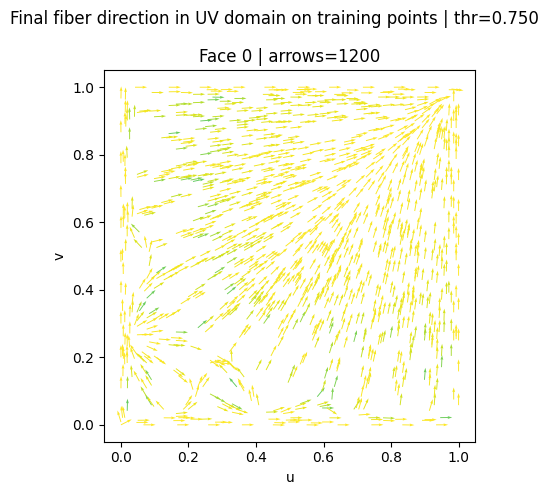

Widget(value='<iframe src="http://localhost:44823/index.html?ui=P_0x7591391b5c30_14&reconnect=auto" class="pyv…

In [10]:
Explanation = "_Torsion_Z"

cfg = TrainingConfig(
    # Case / Reproducibility
    LoadingCasee=LoadingCase,
    training_face_index=0,
    seed_number=30,
    use_Metric_anisotropy=False,
    fixed_height=0.5,
    target_volfrac=0.25,

    # Seed Initialization / Geometry
    seed_repulsion_sigma=0.1,
    boundary_margin=0.05,

    # Training Loop
    num_steps=10000,
    log_every=100,
    early_stop_start=0.5,
    patience=1000,
    min_delta=1e-10,

    # Plateau / Pruning
    prune_inactive_on_plateau=False,
    prune_patience=300,

    # Width Parameters
    freeze_w=False,
    w_const=0.1,
    w_min=0.0005,
    min_feature_size_3d=0.4,
    auto_update_wmin=False,
    w_max_ratio=0.2,
    duplicate_merge_sigma=0.05,

    # Fiber Band Priors
    use_band_weighted_fiber_pairs=True,
    fiber_band_prior_power=2.0,
    fiber_band_prior_floor=0.02,

    # Hollow / Edge Density
    hollow_void_threshold=0.85,
    hollow_edge_threshold=0.45,
    hollow_temp=0.05,
    hollow_rho_edge_min=0.75,

    # Seed Activity
    seed_activity_sharpness=1.5,
    seed_activity_threshold=0.4,
    lam_seed_active=100.0,
    min_active_seeds=2,

    # Boundary Attachment
    use_boundary_attachment=True,
    predict_boundary_params=False,
    boundary_volume_assist=0.0,
    boundary_attach_width=0.001,
    boundary_attach_beta=0.003,
    boundary_attach_alpha=1.0,
    boundary_attach_width_min=5e-6,
    boundary_attach_width_max=5e-5,
    boundary_attach_alpha_min=0.05,
    boundary_attach_alpha_max=1.0,
    boundary_attach_beta_min=0.003,
    boundary_attach_beta_max=0.05,

    # Tau / Temperature
    predict_tau=None,
    tau=0.02,
    tau_pred_start=0.1,
    tau_pred_min=1e-3,
    tau_pred_max=1.0,
    tau_anneal_final=0.03,
    tau__anneal_final=0.03,
    tau_anneal_start_frac=0.0,
    tau_anneal_ramp_frac=0.5,
    beta=0.02,

    # Density Projection
    density_projection_strength=0.8,
    density_projection_threshold=0.75,
    density_projection_gamma=0.04,

    # Rolling Seed Anchors
    use_rolling_seed_anchors=True,
    seed_anchor_momentum=0.08,
    seed_anchor_warmup_frac=0.005,

    # Anchor Guards
    guard_seed_anchor_updates=False,
    anchor_guard_rep_max=0.30,
    anchor_guard_bnd_max=0.80,
    anchor_guard_vol_eff_min=0.10,
    anchor_guard_width_factor_min=1.20,
    anchor_guard_min_seed_dist_factor=2.0,

    # Seed Spacing / Projection
    collapse_min_seed_dist_factor=2,
    project_seed_spacing_each_step=False,
    seed_projection_iters=4,

    # Seed Domain Handling
    allow_seed_outside_domain=True,
    allow_seed_outside_domain_warmup_frac=0.1,
    seed_domain_margin=0.35,
    use_seed_domain_mask=True,
    seed_domain_mask_threshold=0.5,
    seed_domain_temp=0.05,
    seed_domain_mask_support_scale=2.5,
    seed_domain_mask_max_points=2048,

    # Seed Offset Schedule
    Offset_scale=0.5,
    use_independent_seed_offsets=True,
    independent_seed_offset_max=0.05,
    seed_offset_scale_start=0.5,
    seed_offset_scale_final=0.25,
    seed_offset_scale_ramp_frac=1.0,

    # Loss Weights
    lam_fem=50,
    lam_vol=30,
    lam_rep=0,
    lam_bnd=0,
    lam_strut=0.0,
    lam_strut_edge=1.0,
    lam_strut_void=3.0,
    lam_width_active=0,

    # Width Targeting
    width_target_frac=0.04,
    width_target_sparse_boost=1.0,
    width_target_frac_max=0.1,
    width_warmup_start_frac=0,
    width_warmup_ramp_frac=0,
    lam_width_active_hard_multiplier=1.0,
    decoder_raw_temp=1.25,
    w_head_bias_init=None,

    # Loss Normalization / FEM Stability
    comp_normalize_by=None,
    normalize_losses=False,
    fem_density_floor=0.005,
    skip_bad_fem_steps=True,

    # Hard Refine Phase
    hard_refine_start_frac=0.95,
    freeze_tau_head_during_hard_refine=True,
    hard_refine_width_multiplier=1.0,

    # Boundary-Weighted / Effective Volume
    use_boundary_weighted_volume=False,
    boundary_vol_weight=0.2,
    effective_volume_power=2.0,
    lam_vol_effective=4,
    lam_vol_sharp=1,
    sharp_vol_start_frac=0.9,
    sharp_vol_ramp_frac=0.3,

    # Learning Rates
    lr_seed_refine=1e-4,
    lr_independent_seed_offsets=1e-3,
    lr_delta_head=1e-4,
    lr_mlp=1e-4,
    lr_w_head=5e-5,
    lr_h_head=1e-4,
    lr_boundary_heads=1e-4,

    # Numerical / Optimizer Settings
    eps=1e-12,
    scheduler_milestones=(0.75, 0.9),
    scheduler_gamma=0.2,
    save_fem_debug_history=True,
    grad_clip_norm=1.0,

    # TensorBoard Logging
    tensorboard_enabled=True,
    tensorboard_log_root="runs",
    experiment_name=f"{Case_name}{Explanation}",
    tb_flush_secs=10,
    tb_log_histograms_every=100,

    # Timelapse Output
    MakeTimelaps=True,
    timelapse_output_folder=f"Case_Studies/{Case_name}{Explanation}",
    timelapse_frame_step=10,
    TM_laps_res_u=100,
    TM_laps_res_v=100,
    TM_laps_Thr=0.3,

# turn on anomaly detection for debugging
    debug_anomaly_detection = False,
)

trainer = NN_Trainer(
    generator=generator,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
    loading_img=loading_img,
)

print(cfg)

result = trainer.train(
    shape_path,
    face_tensors=tensors["face_tensors"],
)
trainer.visualize_result_stepwise(result, points_xyz, faces_ijk)

threshold= 0.75
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=threshold, show_solid=False)
trainer.Visualize_fresult_final_fiber_Direction_3D( result, points_xyz,faces_ijk,thr=threshold)
out = trainer.visualize_result_final_fiber_direction_2d(result, points_xyz, faces_ijk,thr=threshold)
display(out["figure"])
trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)

In [5]:
Doit_again = False
if(Doit_again):
    threshold= 0.75
    trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=threshold, show_solid=False)
    trainer.Visualize_fresult_final_fiber_Direction_3D( result, points_xyz,faces_ijk,thr=threshold)
    out = trainer.visualize_result_final_fiber_direction_2d(result, points_xyz, faces_ijk,thr=threshold)
    display(out["figure"])
    trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)
    #trainer.visualize_result_final_smooth_surface_pyvista(result, points_xyz, faces_ijk, thr=0.5)
    #print(result["tensorboard_log_dir"])


In [6]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"

shape_path = Planar

Case_name = shape_path.stem
print(Case_name)
generator = CADTensorGenerator(
    deflection=0.001,
    angle=0.001,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=30  ,
    n_v=30,
    freeform_mesher="auto",   #"auto"
    gmsh_size_scale=0.25,
    gmsh_algorithm=6,
    device=device,
    selected_face_index=0,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=str(shape_path),
    input_ring=1,
    mode="mesh", #"1: mesh" "2:Sampled_points "
    M_per_face=2000,
    pool_size_factor=10,
    fps_pool_factor=4,
    use_fps=True,
    triangulation_max_edge_rel=0.1,
)

Planar
Model is meshed using Gmsh tool
MinVolFrac: 0.041380368173122406
Mesh edge length: min=0.0533211 max=0.11153 median=0.0833333


3D density volume fraction (area-weighted): 0.344338


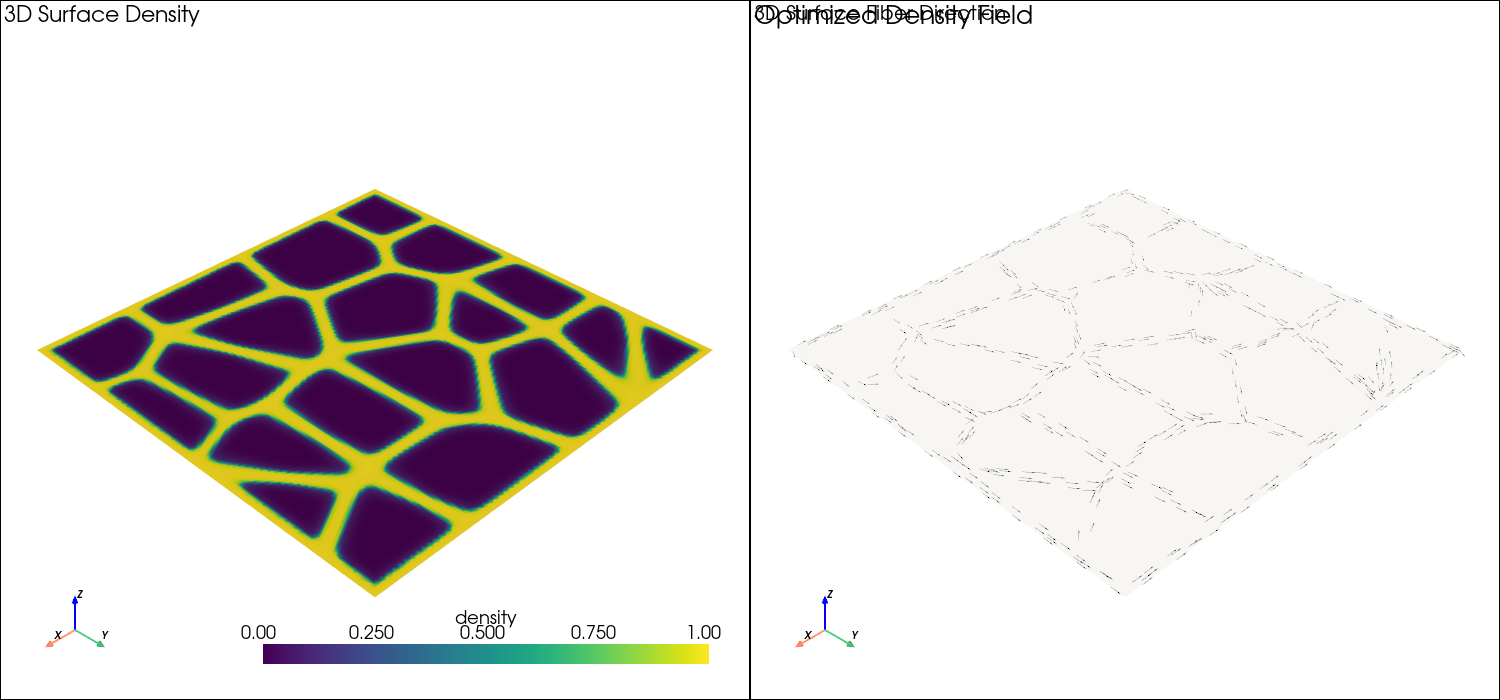

3D density volume fraction (area-weighted): 0.300137


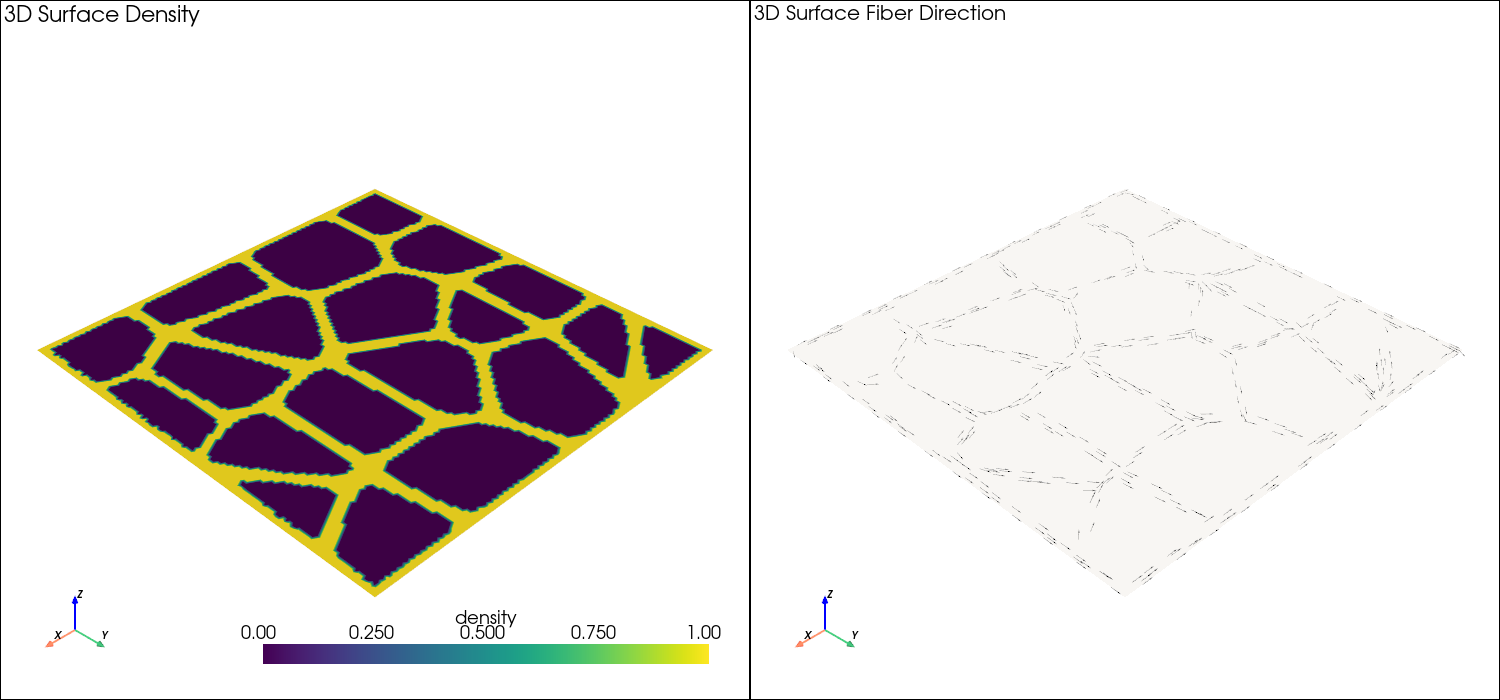

In [7]:
from Training.MainTrain import Load_Model
#ParamPath = result["optimized_function_path"]
OptimizedFunction= Load_Model.load(
    path="Case_Studies/Planar_Test_Compression_Y_p/optimized_shell_function.pt",
    device=device,
)
Fields_Main = Load_Model.evaluate(OptimizedFunction, tensors)

# Fig2D = Load_Model.visualize_2d(fields=Fields_Main,fiber_stride=10,fiber_min_density=0.7)
# display(Fig2D)
Plotter1,VOlFrac_main = Load_Model.visualize_3d(fields=Fields_Main,fiber_stride=10,fiber_min_density=0.7,fiber_scale_3d = 0.25, fiber_color =  "#000000bc")
Plotter1.add_text("Optimized Density Field", font_size=12)
Plotter1.show()
Thr_Val = 0.8
Field_Binary= Load_Model.binarize(fields = Fields_Main, density_threshold=Thr_Val)
# Fig2D = Load_Model.visualize_2d(fields=Field_Binary,fiber_stride=10,fiber_min_density=0.7)
# display(Fig2D)
Plotter2,VOlFrac_Binary= Load_Model.visualize_3d(fields=Field_Binary,fiber_stride=10,fiber_min_density=0.7,fiber_scale_3d = 0.25, fiber_color =  "#000000bc")
Plotter2.show()

Main field -> compliance: 128500.921875, TotalVol_frac: 0.3443
Binary field (0.8) -> compliance: 190646.484375, TotalVol_frac: 0.3001


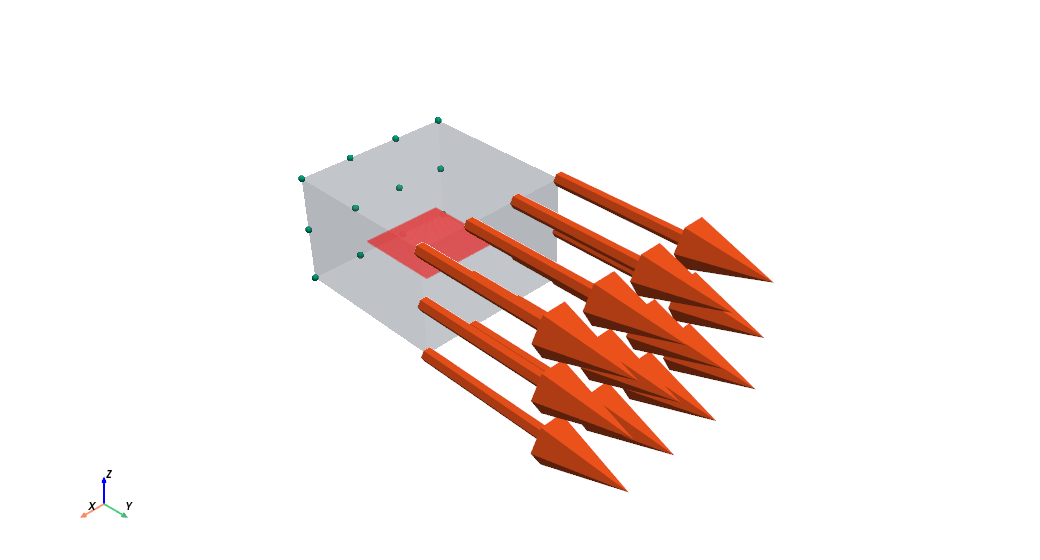

In [8]:
voxel_size = (dx+dy+dz)/40
fixed_height_shell= voxel_size*2
tangential_tol = voxel_size*0.8

shell_problem = ThickenShell(
    thickness=fixed_height_shell,
    BC_dir = "y",
    Load_magnitude=10,
    voxel_size=voxel_size,
    extra_layers=1,
    tensors=tensors,
    tangential_tol=tangential_tol,
    load_case="tensile_compression",
)
# shell_problem =None
# fem =None
fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)

def run_fields_fem(fields, density_floor=0.02):
    rho_surface = fields["3d_density"].to(device)
    fiber_surface = fields["3d_fiberDir"].to(device)

    fem_fields = shell_problem.build_fem_fields_from_decoder_torch(
        rho_surface=rho_surface,
        fiber_surface=fiber_surface,
    )

    density = fem_fields["density"].to(device).float().clamp_min(density_floor)
    phi = fem_fields["phi"].to(device).float()
    theta = fem_fields["theta"].to(device).float()

    return fem(density, phi, theta, penal=3)

stress_main, Compliance_main = run_fields_fem(Fields_Main)
stress_binary, Compliance_binary = run_fields_fem(Field_Binary)

print(f"Main field -> compliance: {float(Compliance_main):.6f}, TotalVol_frac: {VOlFrac_main:.4f}")
print(f"Binary field ({Thr_Val}) -> compliance: {float(Compliance_binary):.6f}, TotalVol_frac: {VOlFrac_Binary:.4f}")


#shell_problem.debug_voxel_stats()
loading_img = shell_problem.show_voxels_surface_and_bc(
    return_img=True,
    off_screen=True,
    window_size=(560, 430),
    show=True,
)



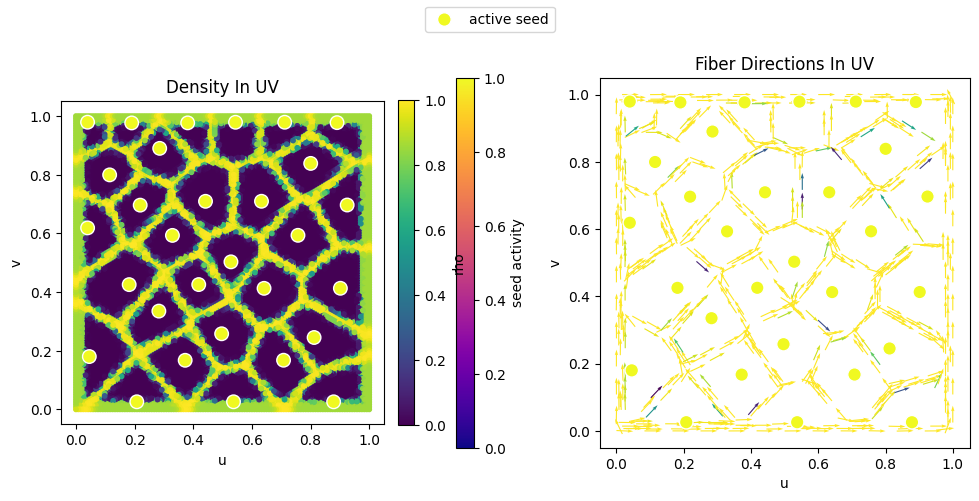

Widget(value='<iframe src="http://localhost:44823/index.html?ui=P_0x7591581c7160_10&reconnect=auto" class="pyv…

Done


In [9]:
#Voronoi visualization
RUN_THIS = True
if  RUN_THIS:
    seeds_raw= torch.tensor([
        [-0.9, 0.20],
        [-0.9, 0.40],
        [-0.9, 0.60],
        [-0.9, 0.80],

        [0.3, 0.40],
        [0.9, 0.20],
        [0.9, 0.40],
        [0.9, 0.60],
        [0.9, 0.80],
        [0.3, 0.40],
        [0.9, 0.20],
        [0.9, 0.40],
        [0.9, 0.60],
        [0.9, 0.80],

    ], dtype=torch.float32)

    seeds_raw = torch.tensor([
       [0.245, 0.586],
        [0.322, 0.583],
        [0.395, 0.546],
        [0.458, 0.490],
        [0.397, 0.434],
        [0.317, 0.344],
        [0.247, 0.344],
        [0.852, 0.508],
        [0.855, 0.444],
    ], dtype=torch.float32)

    # S = 20
    # margin = 0
    # seeds_raw = margin + (1 - 2 * margin) * torch.rand((S, 2), dtype=torch.float32)
    #seeds_raw = generator.fps(uv, K=10, M=10, return_indices=False).cpu()  # FPS seeds from the input UV points
    N= 30
    seeds_raw_index= generator.fps_3d(points_xyz,N,boundary_idx_ring1)
    seeds_raw = uv[seeds_raw_index]
    # face_idx = 0
    # face_tensor = tensors["face_tensors"][face_idx]
    # seeds_raw = result["best_seeds"][face_idx]


    S = seeds_raw.shape[0]
    # symmetric pairwise widths
    w_raw = torch.full((S, S), 5 ,dtype=torch.float32)
    # w_raw = (torch.rand(S, S) * 40) - 20
    # w_raw =  0.5*(w_raw + w_raw.T)
    #print(w_raw)


    # optional anisotropy

    theta = 2 * torch.pi * torch.rand(S, dtype=torch.float32)
    a_raw = 3* torch.randn(S, dtype=torch.float32)



    face_tensor = tensors["face_tensors"][0]   # choose the face you want to test

    uv = face_tensor["uv"]
    Xu = face_tensor["Xu"]
    Xv = face_tensor["Xv"]
    points_xyz = face_tensor["points_xyz"]
    faces_ijk = face_tensor["faces_ijk"]

    Veron_viz = VoronoiModelVisualizer.from_face_tensor(
        face_tensor,
        tau=0.01,
        n_seeds=S,
        seed_domain_temp=0.02,
        seed_domain_mask_threshold=0.5,
        use_metric_anisotropy=False,
        beta=0.01,
        density_projection_strength=0.45,
        density_projection_threshold=0.35,
        density_projection_gamma=0.06,
        w_max_ratio=0.1,
        fixed_height=0.2,
        use_boundary_attachment=True,
        boundary_attach_width_min=1e-6,
        boundary_attach_width_max=2e-2,
        raw_temp=0.01,
        seed_activity_sharpness= 60,
    )
    result = Veron_viz.visualize_fields(
        seeds_raw=seeds_raw,
        w_raw=w_raw,
        theta=None,
        a_raw=None,
        boundary_width_raw=torch.tensor(1.0),
        boundary_alpha_raw=torch.tensor(1),
        boundary_beta_raw=torch.tensor(0.0),
        show_uv=True,
        show_3d=True,
        fiber_stride=10,
        fiber_scale_uv=0.05,
        fiber_scale_3d=0.5,
        fiber_min_strength=0.7,
        show_fiber_density_background=False,
        hard_seed_mask=False,
    )
    display(result["uv_fig"])
    result["plotter"].show()
    print("Done")
